In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from candidate_pooling.analysis.dashboard import (
    source_example_widget,
    top_probe_examples_widget,
    fingerprint_histograms_widget,
    example_fingerprint_widget,
    example_cosine_widget,
    example_gradient_norm_widget,
    example_fingerprint_widget_steered,
    example_steering_curve_widget,
    logit_lens_widget,
    example_activation_dot_widget,
    example_attention_delta_widget,
)

In [3]:
from candidate_pooling.pipeline import MODEL_ID, RUNS_DIR

In [4]:
from candidate_pooling.model import load_nnsight_model
from transformers import LlamaForCausalLM

model = load_nnsight_model(MODEL_ID, model_cls=LlamaForCausalLM, eager_attn=True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [31]:
from runlog import load_run, list_runs, RunBrowser

runs = list_runs(RUNS_DIR)
RunBrowser(RUNS_DIR)

Cannot show ipywidgets in text

In [32]:
from pathlib import Path


run_index = 4
run_name = runs[run_index]
cache_dir = Path(load_run(RUNS_DIR, run_name)[1]) / 'pipeline_cache'

In [36]:
source_example_widget(cache_dir)

Component react.component(candidate_pooling.analysis.dashboard._BasisDropdown) raised exception KeyError(-1)
Traceback (most recent call last):
  File "/home/kobyjl/experiments/candidate-pooling/.venv/lib/python3.12/site-packages/reacton/core.py", line 1702, in _render
    root_element = el.component.f(*el.args, **el.kwargs)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kobyjl/experiments/candidate-pooling/src/candidate_pooling/analysis/dashboard.py", line 76, in _BasisDropdown
    render(basis_dir_list[idx])
  File "/home/kobyjl/experiments/candidate-pooling/src/candidate_pooling/analysis/dashboard.py", line 111, in render
    ex = train_by_id[basis["example_id"]]
         ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^
KeyError: -1


Cannot show ipywidgets in text

In [37]:
example_fingerprint_widget(cache_dir, model)

Cannot show ipywidgets in text

In [11]:
example_fingerprint_widget_steered(cache_dir, model, alpha=4.0)

Cannot show ipywidgets in text

In [12]:
example_steering_curve_widget(cache_dir, model)

Cannot show ipywidgets in text

In [13]:
example_activation_dot_widget(cache_dir, model, exclude_bos=True)

Cannot show ipywidgets in text

In [14]:
example_attention_delta_widget(cache_dir, model, alpha_default=4.0)

Cannot show ipywidgets in text

In [15]:
example_cosine_widget(cache_dir, model)

Cannot show ipywidgets in text

In [16]:
example_gradient_norm_widget(cache_dir, model)

Cannot show ipywidgets in text

In [17]:
top_probe_examples_widget(cache_dir)

Cannot show ipywidgets in text

In [34]:
fingerprint_histograms_widget(cache_dir)

Cannot show ipywidgets in text

In [35]:
logit_lens_widget(cache_dir, model)

Cannot show ipywidgets in text

In [20]:
from candidate_pooling.analysis.analysis import get_option_diff, plot_option_diff
from candidate_pooling.analysis.dashboard import _load_tok_probe, _load_basis

In [21]:
tok_probe = _load_tok_probe(cache_dir)
basis = _load_basis(cache_dir)

In [22]:
from candidate_pooling.analysis.analysis import OptionPreTargeter


diff_result = get_option_diff(tok_probe, OptionPreTargeter(), basis[3]['vector'], model)

100%|██████████| 200/200 [00:05<00:00, 36.21it/s]


In [23]:
diff_result

DiffResults(avg_diff=0.0015476122498512268, avg_diff_by_answer_position=[-0.009788423776626587, 0.01096867024898529, 0.0013731718063354492, 0.0036370307207107544], stddev_diff=0.004682745784521103, stddev_diff_by_answer_position=[0.008170024491846561, 0.009579870849847794, 0.010647006332874298, 0.008886383846402168])

100%|██████████| 200/200 [00:05<00:00, 39.73it/s]


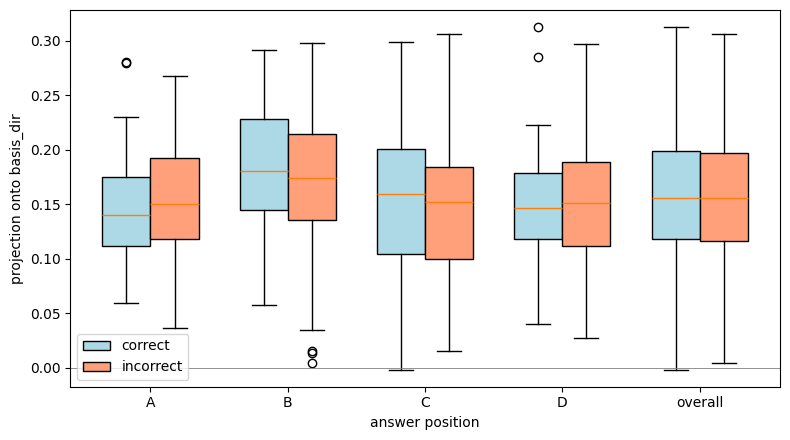

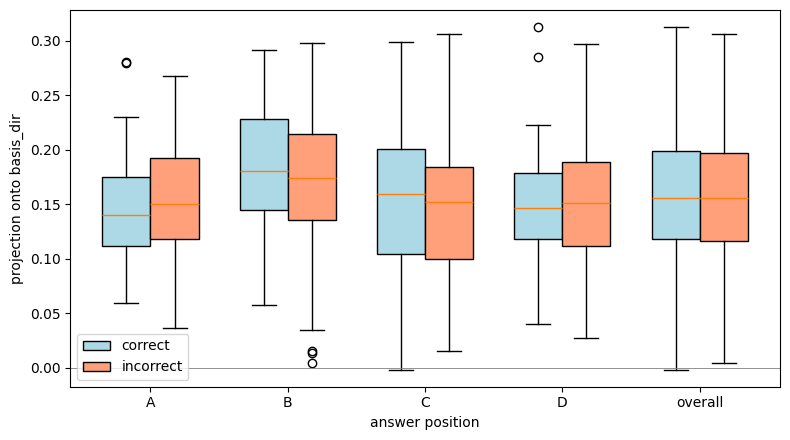

In [24]:
plot_option_diff(tok_probe, OptionPreTargeter(), basis[3]['vector'], model)

In [25]:
from candidate_pooling.data import load_arc_easy, tokenize_dataset
from candidate_pooling.model import PreMarkIncorrectFormatter

arc_easy = load_arc_easy()
epp_train, epp_probe = tokenize_dataset(model, arc_easy, 1000, 200, PreMarkIncorrectFormatter())


In [26]:
example_fingerprint_widget(cache_dir, model, example_splits={
    "probe": list(epp_probe),
    "train": list(epp_train),
})

Cannot show ipywidgets in text

In [27]:
example_activation_dot_widget(cache_dir, model, example_splits={
    "probe": list(epp_probe),
    "train": list(epp_train)
}, exclude_bos=True)

Cannot show ipywidgets in text